In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator

import cplex
from docplex.mp.model import Model
from cplex.callbacks import UserCutCallback, LazyConstraintCallback, SolveCallback
from docplex.mp.callbacks.cb_mixin import ConstraintCallbackMixin

np.set_printoptions(precision=8, suppress=True)

pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000)
pd.set_option('expand_frame_repr', False)

In [2]:
def sort_benchmark(benchmark: pd.DataFrame) -> np.ndarray:
    """
    Ordena um benchmark (DataFrame com uma única coluna)
    em ordem crescente.

    Args:
        benchmark: DataFrame contendo exatamente uma coluna.

    Returns:
        np.ndarray contendo os valores ordenados.
    """

    if benchmark.shape[1] != 1:
        raise ValueError(
            "O DataFrame deve conter exatamente uma coluna."
        )

    col = benchmark.columns[0]

    return np.sort(benchmark[col].values)


def missing_percentage(df, threshold=0):
    """
    Retorna a quantidade e porcentagem de valores ausentes por coluna,
    filtrando colunas com porcentagem maior que o threshold.

    Se nenhuma coluna tiver valores ausentes, retorna uma mensagem.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame analisado.

    threshold : float
        Percentual mínimo de dados ausentes para exibir a coluna.
        Exemplo: threshold=10 mostra apenas colunas com mais de 10% de NaN.
    """

    missing_pct = df.isnull().mean() * 100

    result = pd.DataFrame({
        'missing_count': df.isnull().sum(),
        'missing_percentage': missing_pct
    })

    # mantém apenas colunas com pelo menos 1 NaN
    result = result[result['missing_count'] > 0]

    # verifica se existe alguma coluna com NaN
    if result.empty:
        return "Nenhuma coluna possui dados faltantes."

    # aplica threshold
    result = result[result['missing_percentage'] > threshold]

    return result.sort_values(by='missing_percentage', ascending=False)



def remove_empty_samples(df, threshold):
    """
    Remove colunas onde a porcentagem de valores ausentes (NaN) 
    é maior que o threshold fornecido.
    
    Parâmetros:
    df (pd.DataFrame): O dataframe original.
    threshold (float): Valor entre 0 e 1 (ex: 0.30 para remover colunas com >30% de NaN).
    """
    # Calcula a média de valores nulos por coluna
    # Como True=1 e False=0, a média representa a porcentagem de nulos
    colunas_para_manter = df.columns[df.isnull().mean() <= threshold]
    
    return df[colunas_para_manter]



def fill_missing_data(df):
    """
    Preenche dados ausentes usando ffill seguido de bfill.
    
    O ffill preenche os nulos com o valor anterior.
    O bfill preenche os nulos restantes com o próximo valor.
    """
    return df.ffill().bfill()


def plot_portfolio_comparison(portfolio, force_background=False):
    """
    Plota o comparativo de performance entre o portfólio (estratégia)
    e o benchmark S&P 500, ambos normalizados.
    """
    plt.figure(figsize=(20, 10))

    ax = plt.gca()

    if force_background:
        ax.set_facecolor("white")
        ax.figure.set_facecolor("white")

    # CORREÇÃO AQUI: Convertendo o índice para Datetime para a linha não sumir/cortar
    index_dt = pd.to_datetime(portfolio.index)

    # Plotagem usando o índice convertido em Datetime nativo
    plt.plot(index_dt, portfolio["SSD"], label="SSD Toni")
    plt.plot(index_dt, portfolio["SP500"], label="SP500")

    if "Risk free rate" in portfolio.columns:
        plt.plot(index_dt, portfolio["Risk free rate"], label="Risk free rate", linestyle="--")

    # ============================================================
    # CONFIGURAÇÃO DO EIXO X (Dias 01 e 15 sem quebrar as linhas)
    # ============================================================
    # Localiza matematicamente os dias 1 e 15 de cada mês ao longo da linha do tempo
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=[1, 15]))

    # Formata a exibição exatamente como você quer: Ano-Mês-Dia
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    # ============================================================

    plt.title("Comparativo de Performance dos Portfólios", fontsize=20)
    plt.xlabel("Data", fontsize=16)
    plt.ylabel("Valor normalizado", fontsize=16)

    plt.legend(fontsize=14)
    plt.grid(True, alpha=0.3)   # O grid segue os dias 1 e 15 automaticamente
    plt.xticks(rotation=45)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis='both', colors='gray', labelsize=14)

    plt.tight_layout()
    plt.show()


In [3]:
in_sample_days      = 200
oos_start           = '2024-01-01'
oos_end             = '2024-06-01'

marketData   = pd.read_csv("../../data/marketData.csv", parse_dates=["Date"])
marketData.set_index("Date", inplace=True)
marketData.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 305 entries, 2023-03-16 to 2024-05-31
Columns: 509 entries, SP500 to VUA3RK
dtypes: float64(509)
memory usage: 1.2 MB


In [4]:
missing_percentage(marketData)

,missing_count,missing_percentage
VERNOV,262,85.901639
SOLVEN,261,85.573770
VERALTO,137,44.918033
KENVUE,34,11.147541
2920D5,20,6.557377
CEDFD5,1,0.327869


In [5]:
cleanMarketData = remove_empty_samples(marketData, 0.15) # Remove amostras com mais de 15% ausentes
cleanMarketData = fill_missing_data(cleanMarketData)      # Aplica ffil bfill

print(cleanMarketData.shape)
missing_percentage(cleanMarketData)

(305, 506)


'Nenhuma coluna possui dados faltantes.'

In [6]:
marketDataPrices    = cleanMarketData.copy()

In [7]:
benchmarks = ['SP500']

oosMarketDataPrices = marketDataPrices.loc[oos_start:oos_end]
oosBenchmarkPrices  = oosMarketDataPrices[benchmarks]
oosMarketDataPrices = oosMarketDataPrices.drop(columns=['SP500'])
print(oosBenchmarkPrices.shape, oosMarketDataPrices.shape)

(105, 1) (105, 505)


In [8]:
marketDatareturns = marketDataPrices.diff()[1:] / marketDataPrices.shift(1)[1:]
insampleBenchmarkReturns  = marketDatareturns[benchmarks]
insampleMarketDataReturns = marketDatareturns.drop(columns=['SP500'])
print(insampleBenchmarkReturns.shape, insampleMarketDataReturns.shape)

(304, 1) (304, 505)


In [9]:
insampleMarketDataReturns.shape, insampleBenchmarkReturns.shape, oosMarketDataPrices.shape

((304, 505), (304, 1), (105, 505))

In [10]:
n_cols = 200

insampleMarketDataReturnsCopy = insampleMarketDataReturns.iloc[:, :n_cols]
oosMarketDataPricesCopy       = oosMarketDataPrices.iloc[:, :n_cols]

In [11]:
insampleMarketDataReturnsCopy.shape, insampleBenchmarkReturns.shape, oosMarketDataPricesCopy.shape

((304, 200), (304, 1), (105, 200))

In [12]:
# cav_removed = ["SMCI","DECK","SOLV","GEV","VST","VLTO"]

# portsim_multissd_asset_prices  = pd.read_csv("../../data/portsim-multissd-asset-prices.csv")
# print(len(portsim_multissd_asset_prices.columns), len(insampleMarketDataReturns.columns))

# list(set(portsim_multissd_asset_prices.columns.to_list()) ^ set(insampleMarketDataReturns.columns.to_list()))

insampleMarketDataReturns.columns.to_list()[:n_cols]

['00067A',
 '003B70',
 '013528',
 '0157B1',
 '034B61',
 '03B8CF',
 '03CF95',
 '055018',
 '061366',
 '063384',
 '067779',
 '06EF42',
 '070B45',
 '07EC43',
 '09DE1F',
 '09E31A',
 '09F623',
 '0B57D7',
 '0BC29E',
 '0BF4BA',
 '10646E',
 '1151F4',
 '119CB6',
 '12DE76',
 '12E454',
 '131443',
 '13C3E0',
 '143C52',
 '147C38',
 '1490F3',
 '14BA06',
 '14C7B2',
 '14ED2B',
 '159AE4',
 '15ABD0',
 '164D72',
 '168A5D',
 '16B183',
 '1791E7',
 '17EDA5',
 '17F16B',
 '188394',
 '18EC17',
 '190B91',
 '1921DD',
 '1A3E1B',
 '1BC12C',
 '1D1B07',
 '1D9E55',
 '1EBF8D',
 '1F9D90',
 '1FAF22',
 '205AD5',
 '20BEEA',
 '2158DF',
 '221AD7',
 '228D42',
 '24C48B',
 '24CB56',
 '24D81E',
 '25102A',
 '251988',
 '253B2F',
 '263A36',
 '2667B6',
 '267718',
 '26CC63',
 '275300',
 '2920D5',
 '2B49F4',
 '2B7A40',
 '2BA977',
 '2BAE5F',
 '2BF36E',
 '2CB4C9',
 '2D2D43',
 '2D643C',
 '2DBF98',
 '2E0496',
 '2E61CC',
 '2F94A5',
 '2F98A5',
 '2FEA66',
 '304C94',
 '30A565',
 '315EB0',
 '322A44',
 '32BBAA',
 '32CB22',
 '342218',
 '343996',

In [13]:
insampleMarketDataReturnsCopy.describe()

,00067A,003B70,013528,0157B1,034B61,03B8CF,03CF95,055018,061366,063384,067779,06EF42,070B45,07EC43,09DE1F,09E31A,09F623,0B57D7,0BC29E,0BF4BA,10646E,1151F4,119CB6,12DE76,12E454,131443,13C3E0,143C52,147C38,1490F3,14BA06,14C7B2,14ED2B,159AE4,15ABD0,164D72,168A5D,16B183,1791E7,17EDA5,17F16B,188394,18EC17,190B91,1921DD,1A3E1B,1BC12C,1D1B07,1D9E55,1EBF8D,1F9D90,1FAF22,205AD5,20BEEA,2158DF,221AD7,228D42,24C48B,24CB56,24D81E,25102A,251988,253B2F,263A36,2667B6,267718,26CC63,275300,2920D5,2B49F4,2B7A40,2BA977,2BAE5F,2BF36E,2CB4C9,2D2D43,2D643C,2DBF98,2E0496,2E61CC,2F94A5,2F98A5,2FEA66,304C94,30A565,315EB0,322A44,32BBAA,32CB22,342218,343996,3461CF,34A959,34B97A,351EC3,353DBB,3587B4,35F4B5,366A08,370C50,37727A,385DD4,388E00,39692D,39BFF6,39FB23,3C7F5F,3CBA2A,3CCC90,3D9999,3DC887,3DE4D1,3ED92D,3F4497,3FACA7,3FB145,4030E2,408089,40B903,416C55,41B0E2,420168,431B74,434F38,442769,44A4FC,4595EF,45CF4C,485445,49BBBC,4A5C8D,4A6F00,4A6F00_2,4AC91D,4C37C5,4D371E,4FB770,50070E,504FE2,507AE7,508CFD,51D876,51E682,520632,523A06,543900,55438C,55C9B5,56277A,567F3D,56CC0A,56EA2B,57B174,57CAAB,57DDB9,589803,58B46F,58CA9A,59B229,5A6336,5A9A82,5B6C11,5BC2F4,5CC29D,5DD486,5DE5A5,5E6959,5E7E82,5F2FF7,5F9CE3,60DD84,60F8A4,6137BF,6166D1,616E3B,619882,61B81B,61BCA7,61E975,622DBE,6284B5,636639,63F892,641F17,64CEBB,64E346,652E62,662682,665D7D,66E04A,66ECFD,6844D2,69345C,69CE71,69E8E1,6ABCB8,6B0784,6B236C,6B5379,6BF593
count,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000
mean,-0.000821,-0.000245,0.000078,0.002032,0.001578,0.000851,-0.000270,0.001503,0.001414,0.000568,0.002112,0.001563,0.000504,0.000567,0.002749,-0.005690,0.001257,0.002221,0.001656,0.000402,-0.000027,-0.000418,0.000343,-0.000050,0.002968,0.000862,-0.000373,-0.000333,0.000761,0.001444,0.000463,0.000096,-0.001681,0.000482,0.000689,0.000219,0.001073,0.000110,-0.000224,0.000440,0.000721,-0.001

In [14]:
class SSDLazyCallback(ConstraintCallbackMixin, LazyConstraintCallback, SolveCallback):

    def __init__(self, env):
        LazyConstraintCallback.__init__(self, env)
        ConstraintCallbackMixin.__init__(self)
        self.n_calls   = 0
        self.tolerance = 1e-6
        self.debug = False
        self.cuts_debug = False

    def __call__(self):

        if self.get_cplex_status() == self.status.optimal:
            self.n_calls += 1

            if self.cuts_debug: print('-' * 40)
            if self.cuts_debug: print(f"\n [INFO]: Running separation algorithm #{self.n_calls} ")

            n_scenarios   = len(self.scenarios)
            n_assets      = self.scenarios.shape[1]
            curr_solution = self.make_complete_solution()
            curr_w_values = {var.name: self.get_values(var.index) for var in self.w_vars}
            V_value       = curr_solution[self.model.get_var_by_name('V')]
            w_values      = [self.get_values(w.index) for w in self.w_vars]

            if self.logging_mode > 3:
                print(f"\n{'V':<5}: {V_value:.5f}")
                print(f"Weights:")
                my_array = np.array([w for w in w_values])
                print(f"\n{my_array}")

            # Calculando Tail(R'w) para todo t.
            portfolio_returns = self.scenarios @ w_values

            # Ordenar pelo valor do retorno e Imprimir formatado
            idx_returns = list(enumerate(portfolio_returns))
            sorted_idx_returns  = sorted(idx_returns, key=lambda x: x[1])
            if self.logging_mode > 3:
                for rank, (original_index, value) in enumerate(sorted_idx_returns, start=1):
                    print(f"\t{rank:2}-th worst return: {value: .5f} (index {original_index})")
                print()

            # Ordena os retornos do portfólio e do benchmark
            sorted_p_returns = sorted(portfolio_returns)
            sorted_b_returns = self.benchmark

            # Soma acumulada do Benchmark
            cum_p_returns = np.cumsum(sorted_p_returns)
            cum_b_returns = np.cumsum(sorted_b_returns)

            max_diff  = -np.inf
            max_index = None
            max_ret   = None

            #   Sum(Tail(R_1'w)) - tau_1
            #   Sum(Tail(R_1'w) + Tail(R_2'w)) - tau_2
            #   Sum(Tail(R_1'w) + Tail(R_2'w) + Tail(R_3'w)) - tau_3
            for s, ret in enumerate(cum_p_returns):

                tau_s    = cum_b_returns[s]
                rhs_expr = ret - tau_s
                lhs_expr = V_value

                diff = lhs_expr - rhs_expr
                if self.logging_mode > 3: print(f"\t|Js| = {s + 1:2d}, C: {V_value:.5f} - ({ret:.5f}) <= ({tau_s:.5f}) (Violated by {diff:.5f})")

                if lhs_expr > rhs_expr + self.tolerance:

                    if diff > max_diff:
                        max_diff  = diff
                        max_index = s
                        max_ret   = ret

            if max_index is not None:

                if self.logging_mode > 3:
                    print(f"\n[INFO]: SSD constraint violated to Vs_{max_index}\n")
                    print(f"[INFO]: Violation: {max_diff}\n")

                Vs = self.model.get_var_by_name(f"Vs_{max_index}")

                # Obtém os índices dos |J| piores cenários
                worst_scenario_indices = [idx for idx, _ in sorted_idx_returns[:max_index + 1]]  # max_index é zero-based
                if self.debug: print(f"\tWorst Scenario Indices: {worst_scenario_indices}")

                # Soma os retornos desses cenários
                cumulative_scenario = np.sum(self.scenarios[worst_scenario_indices, :], axis=0)

                # Construção explícita do corte
                scenario_return = self.model.sum(cumulative_scenario[i] * self.w_vars[i] for i in range(n_assets))
                rhs             = cum_b_returns[max_index]

                if self.logging_mode > 3:
                    formatted_values = [f"{ret:.5f}" for ret in cumulative_scenario]
                    if self.debug: print(f"\tWorst Scenario Returns: {formatted_values}")

                if self.logging_mode > 3:
                    print(f"\t{'Cut to be added':<22}: ", end="")
                    for i in range(n_assets):
                        print(f"{cumulative_scenario[i]:.5f} {self.w_vars[i].name} + ", end="")
                    print(f"1 {Vs} <= {rhs:.5f}\n")

                # Adiciona restrição
                cpx_lhs, sense, cpx_rhs = self.linear_ct_to_cplex(Vs <= scenario_return - rhs)

                self.add(cpx_lhs, sense, cpx_rhs)

                if self.logging_mode > 3:
                    print(f"\t\033[92m> Violated constraint added.\033[0m\n")
                    print(f"\t> End of Separation Algorithm.")
                    print('-' * 40)

In [15]:
def solve_ssd(scenarios, benchmark, scaled, logging_mode=0, callback=False, verbose=False,):

    print("\n=== STARTING SSD MODEL ===")
    model = Model(name='SSD')
    n_scenar      = scenarios.shape[0]
    n_assets      = scenarios.shape[1]
    model_verbose = False
    MODEL_NAME    = "multissd"

    scenarios = np.array(scenarios)
    benchmark = np.array(benchmark)

    # Variáveis
    model.parameters.preprocessing.presolve         = 0
    model.parameters.mip.display                    = 4
    model.parameters.threads                        = 1
    model.parameters.emphasis.numerical             = 1
    model.parameters.randomseed                     = 0
    model.parameters.emphasis.mip                   = 2
    model.parameters.simplex.tolerances.optimality  = 1e-9
    model.parameters.simplex.tolerances.feasibility = 1e-9
    model.parameters.timelimit                      = 900
    model.parameters.mip.tolerances.absmipgap       = 0
    model.parameters.mip.tolerances.mipgap          = 0
    model.parameters.mip.tolerances.integrality     = 0

    # Variáveis
    w  = model.continuous_var_list(n_assets, lb=0, ub=1, name='wl')
    Vs = model.continuous_var_list(n_scenar, name='Vs', lb=-model.infinity, ub=model.infinity)
    V  = model.continuous_var(name="V", lb=-model.infinity, ub=model.infinity)
    cb = model.binary_var(name='cb_temp')

    # Restrições básicas
    model.add_constraint(model.sum(w) == 1, ctname="budget")
        
    for t in range(n_scenar): model.add_constraint(V <= Vs[t] , ctname=f"maxmin_{t}")

    # Inicializamos a restrição válida apenas para s = S (onde a ordem não importa)
    total_p_return = model.sum(w[i] * sum(scenarios[:, i]) for i in range(n_assets))
    total_b_return = sum(benchmark)

    # Vs[n_scenar - 1] corresponde à variável do nível S
    model.add_constraint(Vs[n_scenar - 1] <= total_p_return - total_b_return, ctname="ssd_base_S")

    model.maximize(V + 0.0 * cb)


    if logging_mode == 3:
        for ct in model.iter_constraints():
            print(f"Name: {ct.name}, Expression: {ct.left_expr} {ct.sense} {ct.right_expr}")


    model.export_as_lp(f"../../models/toni-{MODEL_NAME}-model.lp")

    if logging_mode == 2:
        print(model.print_information())

    if callback:
        # Registra o callback e passa os parâmetros necessários
        lazy_cb = model.register_callback(SSDLazyCallback)
        lazy_cb.scenarios      = scenarios
        lazy_cb.benchmark      = benchmark
        lazy_cb.scaled         = scaled
        lazy_cb.w_vars         = w
        lazy_cb.logging_mode   = logging_mode

        model.lazy_callback = lazy_cb

    print("\nIniciando processo de otimização...")
    if logging_mode > 0: model_verbose = True
    sol = model.solve(log_output=model_verbose)

    if sol:
        optimized_weights = [sol[wi] for wi in w]
        weights           = np.array(optimized_weights)
        print("\n[INFO]: Solução encontrada:")
        print(f"\tV              {sol[V]}")
        print(f"\tBest Solution = {sol.get_objective_value()}")
        print(f"\tNº of Cuts    = {model.get_cuts()['user']}")
        print()

        return sol[V], sol.get_objective_value(), weights
    else:
        raise RuntimeError("No solution found for the optimization problem!")

In [16]:
def WFV(prices, returns, benchmark, scaled, logging_mode=0, sliding=True):

    INITIAL_CAPITAL       = 1000000

    portfolio_shares_held = pd.DataFrame()
    weights_invested      = pd.DataFrame()
    rebalances_df         = pd.DataFrame()
    optInfoData           = pd.DataFrame()
    valuation_df          = pd.DataFrame()
    shares_df             = pd.DataFrame()
    norm_portfolio_df     = pd.DataFrame(columns=["SSD"])

    print('---------------------------------------------------------------')
    print('[INFO]: Simulation Started...\n')

    initial_train_days = 200
    validation_days    = 1
    rebalance_freq     = 21

    data_length = len(returns)
    # max_steps   = data_length - initial_train_days + 1
    max_steps = len(prices)

    last_share = None


    for step in range(0, max_steps, validation_days):

        train_start = step if sliding else 0
        train_end   = train_start + initial_train_days

        train           = returns.iloc[train_start:train_end]
        train_bench     = benchmark.iloc[train_start:train_end]
        valid           = returns.iloc[train_end-1:train_end]

        train_bench_sorted     = sort_benchmark(train_bench)

        if logging_mode == 4:
            print(f"\nRef:")
            print(np.array(train_bench).flatten())

            for i, col in enumerate(train.columns):
                print(f"\nAsset: {i} - {col}")
                valores_array = train[col].to_numpy()
                print(f"\n{valores_array}")

            print("------------- END INSTANCE - --------------")

            print("All references:")
            print(f"\nRef:")
            print(np.array(train_bench).flatten())

            print(f"\nSorted Ref:")
            print(np.array(train_bench_sorted))


        v_value, func_obj, weights_arr = solve_ssd(train, train_bench_sorted, scaled, logging_mode= logging_mode, callback=True, verbose=False)

        v_df        = pd.DataFrame([v_value], columns=['obj'], index=valid.index)
        weights_opt = pd.DataFrame([weights_arr], columns=valid.columns, index=valid.index)

        print(f"Day: {step + 1} ({valid.index.min()})")
        print(f"\tSum proportions: {np.sum(weights_arr)*100}%")
        print(f"\tFUNÇÃO OBJETIVO: {func_obj}")

        # ============================================================
        # SIMULATION
        # ============================================================

        price = np.array(prices.loc[prices.index[step], :])

        # ============================================================
        # DIA 0 — primeiro dia da simulação
        # ============================================================
        if step == 0:
            print(f"\n\t\033[92mToday is a rebalancing day.\033[0m")

            valuation     = (weights_arr * INITIAL_CAPITAL)
            share         = (valuation / price)
            rebalances_df = pd.concat([rebalances_df, weights_opt])

            optInfoData   = pd.concat([optInfoData, v_df])

            train.to_csv(f"rebalanceInsampleWeights-{valid.index.min().strftime('%Y-%m-%d')}.csv", index=False)

        # ============================================================
        # DIA DE REBALANCEAMENTO
        # ============================================================
        elif step % rebalance_freq == 0:

            print(f"\n\t\033[92mToday is a rebalancing day.\033[0m")

            data_str = valid.index.min().strftime('%Y-%m-%d')
            train.to_csv(f"rebalanceInsampleWeights-{data_str}.csv", index=False)
            optInfoData = pd.concat([optInfoData, v_df])
            
            valuation_normal = (last_share * price)
            total_value      = np.sum(valuation_normal)

            print(f"\tValuation before rebalance: {total_value}")

            valuation     = (weights_arr * total_value)
            share         = (valuation / price)
            rebalances_df = pd.concat([rebalances_df, weights_opt])

        # ============================================================
        # DIA SEM REBALANCEAMENTO
        # ============================================================
        else:
            share     = last_share
            valuation = share * price

        # ============================================================
        # Armazenamento
        # ============================================================
        # break

        date_idx = valid.index[0]

        valuation_df     = pd.concat([valuation_df,pd.DataFrame([valuation], index=[date_idx], columns=valid.columns)])

        shares_df        = pd.concat([shares_df, pd.DataFrame([share], index=[date_idx], columns=valid.columns)])
        weights_invested = pd.concat([weights_invested, weights_opt])

        norm_portfolio_df.loc[date_idx, "SSD"] = (np.sum(valuation) / INITIAL_CAPITAL)

        last_share = share

        print(f"\tPortfolio Value: {np.sum(valuation)}")
        print(f"\tNorm Portfolio: {np.sum(valuation)/INITIAL_CAPITAL}")
        print('---------------------------------------------------------------\n')
        
    return (norm_portfolio_df, weights_invested, rebalances_df, valuation_df, shares_df, optInfoData)

In [17]:
if __name__ == "__main__":
    
    os.system('cls' if os.name == 'nt' else 'clear')


    portfolio, weightsInvested, weightsRebalance, portfolioValuation, portfolioShares, optmizationInfoData = WFV(oosMarketDataPricesCopy,
                                                                                                                 insampleMarketDataReturnsCopy,
                                                                                                                 insampleBenchmarkReturns,
                                                                                                                 scaled       = 0,
                                                                                                                 logging_mode = 1, 
                                                                                                                 sliding      = True)
    print('\n==========================================================')
    print('Finalising simulation...')

---------------------------------------------------------------
[INFO]: Simulation Started...


=== STARTING SSD MODEL ===

Iniciando processo de otimização...
Version identifier: 22.1.2.0 | 2024-11-26 | 0edbb82fd
CPXPARAM_Preprocessing_Presolve                  0
CPXPARAM_Read_DataCheck                          1
CPXPARAM_Threads                                 1
CPXPARAM_Emphasis_Numerical                      1
CPXPARAM_RandomSeed                              0
CPXPARAM_MIP_Display                             4
CPXPARAM_Emphasis_MIP                            2
CPXPARAM_Simplex_Tolerances_Optimality           1.0000000000000001e-09
CPXPARAM_Simplex_Tolerances_Feasibility          1.0000000000000001e-09
CPXPARAM_TimeLimit                               900
CPXPARAM_MIP_Tolerances_AbsMIPGap                0
CPXPARAM_MIP_Tolerances_MIPGap                   0
CPXPARAM_MIP_Tolerances_Integrality              0
Legacy callback                                  LD
Lazy constraint(s) or lazy 

In [18]:
print(optmizationInfoData)

                 obj
Date                
2024-01-02  0.008930
2024-02-01  0.009333
2024-03-04  0.009497
2024-04-03  0.009534
2024-05-02  0.008813


In [19]:
print(portfolio.shape)
portfolio.head()

(105, 1)


,SSD
2024-01-02,1.0
2024-01-03,0.995969
2024-01-04,0.997802
2024-01-05,0.997195
2024-01-08,1.004639


In [20]:
weightsRebalance = weightsRebalance.loc[:, (weightsRebalance != 0).any(axis=0)]
print(weightsRebalance.shape)
weightsRebalance.head()

(5, 40)


,0157B1,034B61,055018,06EF42,119CB6,12E454,1490F3,14C7B2,17EDA5,1EBF8D,1FAF22,205AD5,228D42,24C48B,251988,2667B6,267718,2E61CC,2F98A5,3DC887,3DE4D1,3FACA7,4595EF,485445,4A5C8D,4A6F00,4A6F00_2,4AC91D,504FE2,508CFD,57CAAB,57DDB9,589803,5DD486,5DE5A5,616E3B,61E975,622DBE,662682,69CE71
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-02,0.000000,0.024406,0.000000,0.000000,0.000000,0.019437,0.000000,0.022409,0.000000,0.002000,0.025243,0.027387,0.056046,0.010848,0.000000,0.000000,0.000000,0.156437,0.026647,0.000000,0.086317,0.094617,0.017599,0.000000,0.062238,0.036766,0.000000,0.000000,0.000000,0.032087,0.049641,0.031130,0.005781,0.039520,0.000000,0.046690,0.000000,0.072782,0.034355,0.019618
2024-02-01,0.001855,0.000000,0.030106,0.005676,0.000000,0.041459,0.000000,0.083112,0.000000,0.009324,0.025628,0.043946,0.047282,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.073127,0.072690,0.000350,0.000000,0.081453,0.020209,0.000000,0.054557,0.000000,0.070321,0.121013,0.000000,0.000000,0.109250,0.000000,0.043287,0.007156,0.041549,0.000000,0.016648
2024-03-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.023604,0.018694,0.106333,0.022909,0.024066,0.037598,0.053189,0.001986,0.000000,0.000000,0.000000,0.005403,0.000000,0.000000,0.017912,0.012890,0.076906,0.000000,0.002449,0.049455,0.000000,0.000000,0.013116,0.035097,0.042437,0.156873,0.000000,0.000000,0.117016,0.000000,0.083580,0.043223,0.023564,0.000000,0.031700
2024-04-03,0.000000,0.000000,0.000000,0.010397,0.000000,0.007972,0.007995,0.142792,0.009247,0.023549,0.000000,0.031935,0.038193,0.000000,0.056865,0.002277,0.000000,0.000000,0.000000,0.000000,0.015738,0.083292,0.007720,0.018697,0.083278,0.000000,0.004700,0.000000,0.000000,0.017230,0.138395,0.000000,0.000000,0.161153,0.000000,0.000000,0.088019,0.023672,0.000000,0.026883
2024-05-02,0.000000,0.000000,0.002842,0.010026,0.053789,0.018249,0.000000,0.025397,0.000000,0.000000,0.000000,0.069883,0.020664,0.001304,0.022723,0.049134,0.000000,0.187976,0.000000,0.000000,0.021048,0.118952,0.004545,0.000000,0.000000,0.000000,0.041207,0.000000,0.065159,0.000000,0.118004,0.025965,0.000000,0.008557,0.012135,0.100815,0.000000,0.000000,0.000000,0.021623


In [21]:
portfolioValuation = portfolioValuation.loc[:, (portfolioValuation != 0).any(axis=0)]
print(portfolioValuation.shape)
portfolioValuation.head()

(105, 40)


,0157B1,034B61,055018,06EF42,119CB6,12E454,1490F3,14C7B2,17EDA5,1EBF8D,1FAF22,205AD5,228D42,24C48B,251988,2667B6,267718,2E61CC,2F98A5,3DC887,3DE4D1,3FACA7,4595EF,485445,4A5C8D,4A6F00,4A6F00_2,4AC91D,504FE2,508CFD,57CAAB,57DDB9,589803,5DD486,5DE5A5,616E3B,61E975,622DBE,662682,69CE71
2024-01-02,0.0,24406.127543,0.0,0.0,0.0,19436.569565,0.0,22409.101440,0.0,2000.323452,25242.603387,27386.586137,56045.735044,10847.998474,0.0,0.0,0.0,156437.018596,26646.658236,0.0,86317.477170,94616.954284,17598.797361,0.0,62237.625432,36765.752046,0.0,0.0,0.0,32087.221324,49641.135902,31129.594393,5781.441494,39519.944488,0.0,46690.128989,0.0,72782.158725,34354.593129,19618.453386
2024-01-03,0.0,23906.233398,0.0,0.0,0.0,19334.416639,0.0,21885.301271,0.0,2027.349965,24774.792421,27523.177682,56004.935904,10697.673281,0.0,0.0,0.0,155490.485006,26691.916428,0.0,85880.132101,95645.618742,17712.649814,0.0,63147.357566,36965.320646,0.0,0.0,0.0,32030.944863,49616.974341,31162.277239,5861.678965,38042.880798,0.0,46409.367071,0.0,71682.818697,33848.742548,19625.731356
2024-01-04,0.0,23981.052342,0.0,0.0,0.0,19483.152746,0.0,21885.301271,0.0,2066.918181,25099.640356,27695.316584,55602.955233,10696.043269,0.0,0.0,0.0,156342.409811,26455.410948,0.0,86437.369511,95314.430052,17552.845903,0.0,62386.172092,36292.105300,0.0,0.0,0.0,32538.054852,50274.168810,31204.573857,5827.245724,38294.087042,0.0,46476.961868,0.0,72692.160300,33668.096931,19535.943358
2024-01-05,0.0,23898.309299,0.0,0.0,0.0,19754.253071,0.0,21614.908873,0.0,2070.627407,25444.017272,27287.059929,55574.239033,10655.881119,0.0,0.0,0.0,155048.754473,26344.353272,0.0,86239.886176,95286.259979,17032.433501,0.0,62864.707390,36116.496738,0.0,0.0,0.0,33749.397904,50316.451542,31410.304608,5833.634469,37623.552009,0.0,46211.800807,0.0,73321.943329,33738.626751,19756.761183
2024-01-08,0.0,24281.872811,0.0,0.0,0.0,20130.869218,0.0,21506.694582,0.0,2073.455456,26425.161463,27243.390049,56623.010586,10853.969583,0.0,0.0,0.0,156384.421015,26533.557656,0.0,86917.092978,94306.931216,17879.754570,0.0,62659.622730,36944.016872,0.0,0.0,0.0,32988.888380,50632.967996,31417.987664,5767.898049,37797.338436,0.0,46333.985226,0.0,75740.573769,33618.190388,19577.211557


In [22]:
weightsInvested = weightsInvested.loc[:, (weightsInvested != 0).any(axis=0)]
print(weightsInvested.shape)
weightsInvested.head()

(105, 52)


,00067A,0157B1,034B61,055018,06EF42,0BC29E,119CB6,12E454,1490F3,14C7B2,17EDA5,1EBF8D,1FAF22,205AD5,228D42,24C48B,251988,2667B6,267718,2BAE5F,2E61CC,2F98A5,30A565,34B97A,35F4B5,366A08,3C7F5F,3DC887,3DE4D1,3FACA7,434F38,4595EF,485445,4A5C8D,4A6F00,4A6F00_2,4AC91D,504FE2,508CFD,523A06,57CAAB,57DDB9,589803,5DD486,5DE5A5,616E3B,61E975,622DBE,636639,662682,66ECFD,69CE71
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-02,0.0,0.0,0.024406,0.000000,0.000000,0.000000,0.0,0.019437,0.0,0.022409,0.0,0.002000,0.025243,0.027387,0.056046,0.010848,0.00000,0.0,0.0,0.0,0.156437,0.026647,0.0,0.0,0.0,0.0,0.0,0.0,0.086317,0.094617,0.0,0.017599,0.0,0.062238,0.036766,0.0,0.000000,0.000000,0.032087,0.0,0.049641,0.031130,0.005781,0.039520,0.0,0.046690,0.000000,0.072782,0.0,0.034355,0.0,0.019618
2024-01-03,0.0,0.0,0.024224,0.000000,0.000000,0.000000,0.0,0.019403,0.0,0.022997,0.0,0.000000,0.025012,0.027681,0.055968,0.012417,0.00097,0.0,0.0,0.0,0.155393,0.025284,0.0,0.0,0.0,0.0,0.0,0.0,0.087244,0.095969,0.0,0.017492,0.0,0.063525,0.037151,0.0,0.000000,0.000000,0.031824,0.0,0.048425,0.033819,0.005980,0.039366,0.0,0.046919,0.000000,0.072312,0.0,0.031564,0.0,0.019060
2024-01-04,0.0,0.0,0.024385,0.000000,0.000000,0.000000,0.0,0.019447,0.0,0.022386,0.0,0.002054,0.025216,0.027405,0.056009,0.010862,0.00000,0.0,0.0,0.0,0.156500,0.026664,0.0,0.0,0.0,0.0,0.0,0.0,0.086302,0.094610,0.0,0.017608,0.0,0.062158,0.036758,0.0,0.000000,0.000000,0.032107,0.0,0.049638,0.031114,0.005759,0.039513,0.0,0.046693,0.000000,0.072772,0.0,0.034396,0.0,0.019644
2024-01-05,0.0,0.0,0.024385,0.000000,0.000000,0.000000,0.0,0.019447,0.0,0.022386,0.0,0.002054,0.025216,0.027405,0.056009,0.010862,0.00000,0.0,0.0,0.0,0.156500,0.026664,0.0,0.0,0.0,0.0,0.0,0.0,0.086302,0.094610,0.0,0.017608,0.0,0.062158,0.036758,0.0,0.000000,0.000000,0.032107,0.0,0.049638,0.031114,0.005759,0.039513,0.0,0.046693,0.000000,0.072772,0.0,0.034396,0.0,0.019644
2024-01-08,0.0,0.0,0.000000,0.039725,0.011736,0.000687,0.0,0.000000,0.0,0.116172,0.0,0.018552,0.025330,0.031994,0.057044,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.065647,0.067514,0.0,0.000000,0.0,0.076770,0.040449,0.0,0.020311,0.009917,0.031966,0.0,0.141446,0.005080,0.000000,0.132746,0.0,0.023468,0.023595,0.028693,0.0,0.000000,0.0,0.031159


In [23]:
portfolioShares = portfolioShares.loc[:, (portfolioShares != 0).any(axis=0)]
print(portfolioShares.shape)
portfolioShares.head()

(105, 40)


,0157B1,034B61,055018,06EF42,119CB6,12E454,1490F3,14C7B2,17EDA5,1EBF8D,1FAF22,205AD5,228D42,24C48B,251988,2667B6,267718,2E61CC,2F98A5,3DC887,3DE4D1,3FACA7,4595EF,485445,4A5C8D,4A6F00,4A6F00_2,4AC91D,504FE2,508CFD,57CAAB,57DDB9,589803,5DD486,5DE5A5,616E3B,61E975,622DBE,662682,69CE71
2024-01-02,0.0,7.115111,0.0,0.0,0.0,56.519269,0.0,716.650936,0.0,18.828558,680.452314,53.262447,153.726977,56.014157,0.0,0.0,0.0,1114.355533,224.494998,0.0,770.51633,761.353311,-156.670501,0.0,132.749472,268.309492,0.0,0.0,0.0,3109.196745,120.807807,199.042909,6.431191,201.561618,0.0,267.596186,0.0,2059.460525,178.556506,263.69456
2024-01-03,0.0,7.115111,0.0,0.0,0.0,56.519269,0.0,716.650936,0.0,18.828558,680.452314,53.262447,153.726977,56.014157,0.0,0.0,0.0,1114.355533,224.494998,0.0,770.51633,761.353311,-156.670501,0.0,132.749472,268.309492,0.0,0.0,0.0,3109.196745,120.807807,199.042909,6.431191,201.561618,0.0,267.596186,0.0,2059.460525,178.556506,263.69456
2024-01-04,0.0,7.115111,0.0,0.0,0.0,56.519269,0.0,716.650936,0.0,18.828558,680.452314,53.262447,153.726977,56.014157,0.0,0.0,0.0,1114.355533,224.494998,0.0,770.51633,761.353311,-156.670501,0.0,132.749472,268.309492,0.0,0.0,0.0,3109.196745,120.807807,199.042909,6.431191,201.561618,0.0,267.596186,0.0,2059.460525,178.556506,263.69456
2024-01-05,0.0,7.115111,0.0,0.0,0.0,56.519269,0.0,716.650936,0.0,18.828558,680.452314,53.262447,153.726977,56.014157,0.0,0.0,0.0,1114.355533,224.494998,0.0,770.51633,761.353311,-156.670501,0.0,132.749472,268.309492,0.0,0.0,0.0,3109.196745,120.807807,199.042909,6.431191,201.561618,0.0,267.596186,0.0,2059.460525,178.556506,263.69456
2024-01-08,0.0,7.115111,0.0,0.0,0.0,56.519269,0.0,716.650936,0.0,18.828558,680.452314,53.262447,153.726977,56.014157,0.0,0.0,0.0,1114.355533,224.494998,0.0,770.51633,761.353311,-156.670501,0.0,132.749472,268.309492,0.0,0.0,0.0,3109.196745,120.807807,199.042909,6.431191,201.561618,0.0,267.596186,0.0,2059.460525,178.556506,263.69456


In [24]:
sp500_prices = pd.read_csv('../../data/extracted_SP500_data.csv', parse_dates=['date'])
sp500_prices.set_index('date', inplace=True)
sp500_slice = sp500_prices.loc[oos_start:oos_end, 'SP500'].abs()
sp500 = sp500_slice / sp500_slice.iloc[0]
portfolio['SP500'] = sp500
portfolio['Risk free rate'] = 1.0

In [25]:
portfolio.head(20)

,SSD,SP500,Risk free rate
2024-01-02,1.0,1.000000,1.0
2024-01-03,0.995969,0.991984,1.0
2024-01-04,0.997802,0.988583,1.0
2024-01-05,0.997195,0.990388,1.0
2024-01-08,1.004639,1.004367,1.0
2024-01-09,1.009075,1.002882,1.0
2024-01-10,1.010329,1.008565,1.0
2024-01-11,1.010771,1.007888,1.0
2024-01-12,1.011026,1.008645,1.0
2024-01-16,1.007051,1.004881,1.0


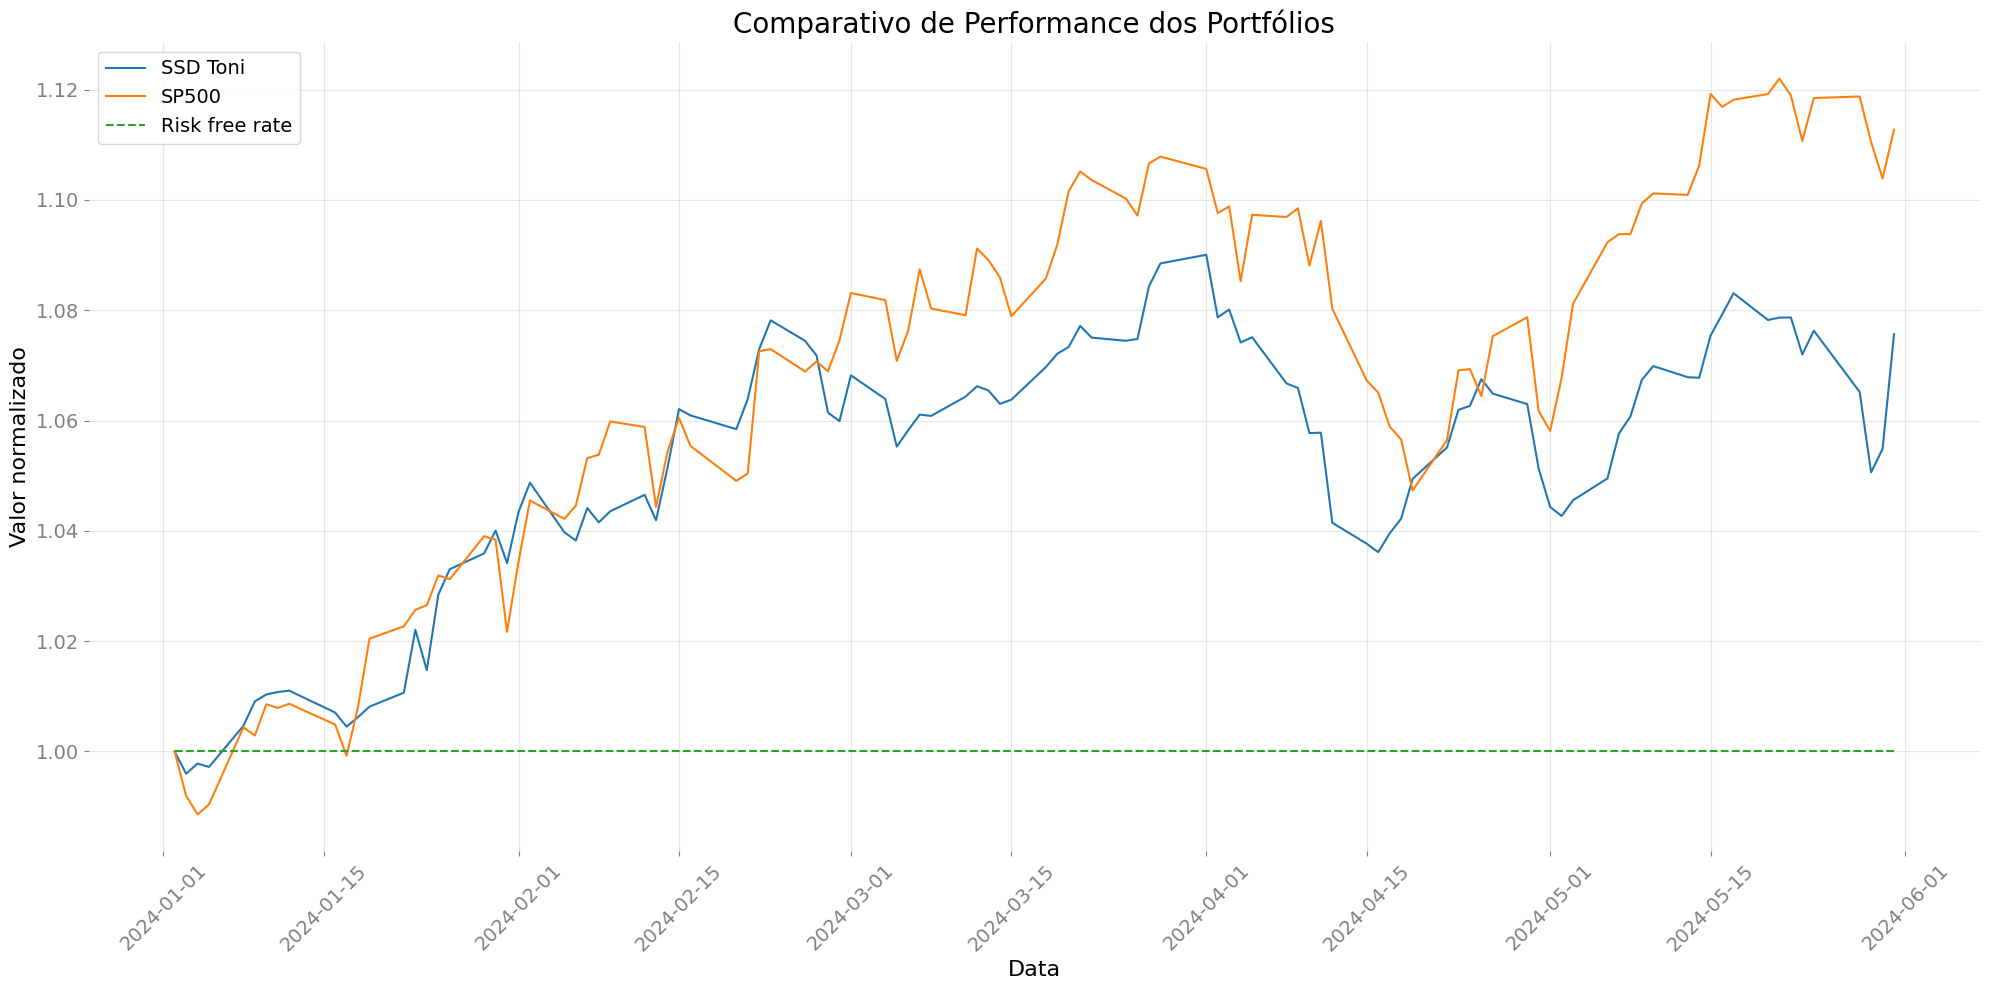

In [26]:
plot_portfolio_comparison(portfolio, force_background=True)